In [31]:
import random
import matplotlib.pyplot as plt
import math
from ipywidgets import interact_manual
import ipywidgets as widgets
import matplotlib.patches as patches
from IPython.display import clear_output
import time

In [35]:
#Challenge 2: Brownium Motion, Random Walk for the small particles

def Expirement(SmallCount,SmallRadius,SmallSpeed,SmallMass,LargeRadius,LargeMass,BoxLength,runTime,TimeSteps):    
    global BigX
    global BigY
    global SmallX
    global SmallY
    global Length
    global sRad
    global bRad
    
    sRad=SmallRadius
    bRad=LargeRadius
    Length=BoxLength

    BigX=[0]
    BigY=[0]
    BigSpeedAngle=0
    BigSpeed=0
    SmallX=[]
    SmallY=[]
    Time=0
    BigXPos=0
    BigYPos=0

    for x in range(SmallCount):
        YouShallNotPass=True
        while YouShallNotPass:
            xPos=random.uniform(-BoxLength/2,BoxLength/2)
            yPos=random.uniform(-BoxLength/2,BoxLength/2)
            if abs(xPos)>LargeRadius or abs(yPos)>LargeRadius:
                YouShallNotPass=False
        
        SmallX.append([xPos])
        SmallY.append([yPos])

    while Time<=runTime:
        Time+=TimeSteps
        for x in range(SmallCount):
            randomAngle=math.pi*2*random.random()
            dx=SmallSpeed*math.cos(randomAngle)
            dy=SmallSpeed*math.sin(randomAngle)
            Posx=SmallX[x][-1]+dx*TimeSteps
            Posy=SmallY[x][-1]+dy*TimeSteps

            if Posx<(-BoxLength/2):
                Posx=-BoxLength/2
            elif Posx>(BoxLength/2):
                Posx=BoxLength/2

            if Posy<(-BoxLength/2):
                Posy=-BoxLength/2
            elif Posy>(BoxLength/2):
                Posy=BoxLength/2

            SmallX[x].append(Posx)
            SmallY[x].append(Posy)

            if math.sqrt((Posx-BigXPos)**2+(Posy-BigYPos)**2)<SmallRadius+LargeRadius:
                Largedx=BigSpeed*math.cos(BigSpeedAngle)
                Largedy=BigSpeed*math.sin(BigSpeedAngle)

                BigXSpeed = (2*SmallMass*dx + (LargeMass-SmallMass)*Largedx) / (LargeMass+SmallMass)
                BigYSpeed = (2*SmallMass*dy + (LargeMass-SmallMass)*Largedy) / (LargeMass+SmallMass)

                BigSpeed=math.sqrt(BigXSpeed**2+BigYSpeed**2)
                BigSpeedAngle=math.atan2(BigYSpeed, BigXSpeed) 

        BigXPos+=BigSpeed*math.cos(BigSpeedAngle)*TimeSteps
        BigYPos+=BigSpeed*math.sin(BigSpeedAngle)*TimeSteps

        if BigXPos-LargeRadius<(-BoxLength/2):
            BigXPos=(-BoxLength/2)+LargeRadius
            BigSpeedAngle=math.atan2(BigSpeed*math.sin(BigSpeedAngle), -BigSpeed*math.cos(BigSpeedAngle)) 

        elif BigXPos+LargeRadius>(BoxLength/2):
            BigXPos=(BoxLength/2)-LargeRadius
            BigSpeedAngle=math.atan2(BigSpeed*math.sin(BigSpeedAngle), -BigSpeed*math.cos(BigSpeedAngle)) 

        if BigYPos-LargeRadius<(-BoxLength/2):
            BigYPos=(-BoxLength/2)+LargeRadius
            BigSpeedAngle=math.atan2(-BigSpeed*math.sin(BigSpeedAngle), BigSpeed*math.cos(BigSpeedAngle)) 

        elif BigYPos+LargeRadius>(BoxLength/2):
            BigYPos=(BoxLength/2)-LargeRadius
            BigSpeedAngle=math.atan2(-BigSpeed*math.sin(BigSpeedAngle), BigSpeed*math.cos(BigSpeedAngle)) 

        BigX.append(BigXPos)
        BigY.append(BigYPos)

interact_manual(
    Expirement,
    SmallCount=widgets.IntSlider(value=1, min=1,max=100,step=1,description='Number of Small Particles'),
    SmallRadius=widgets.FloatSlider(value=1, min=0.01,max=10,step=0.01,description='Radius of Small Particles'),
    SmallSpeed=widgets.FloatSlider(value=1, min=0.01,max=10,step=0.01,description='Speed of Small Particles'),
    SmallMass=widgets.FloatSlider(value=1, min=0.01,max=10,step=0.01,description='Mass of Small Particles'),
    LargeRadius=widgets.FloatSlider(value=10, min=10,max=100,step=0.1,description='Radius of The Large Particle'),
    LargeMass=widgets.FloatSlider(value=10, min=10,max=100,step=0.1,description='Mass of The Large Particle'),
    BoxLength=widgets.FloatSlider(value=11, min=11,max=1100,step=1,description='Length of the Box'),
    runTime=widgets.FloatSlider(value=3600, min=10,max=5000,step=1,description='Simulation Length'),
    TimeSteps=widgets.FloatSlider(value=0.1, min=0.1,max=5,step=0.1,description='Time Steps')
)

interactive(children=(IntSlider(value=1, description='Number of Small Particles', min=1), FloatSlider(value=1.…

<function __main__.Expirement(SmallCount, SmallRadius, SmallSpeed, SmallMass, LargeRadius, LargeMass, BoxLength, runTime, TimeSteps)>

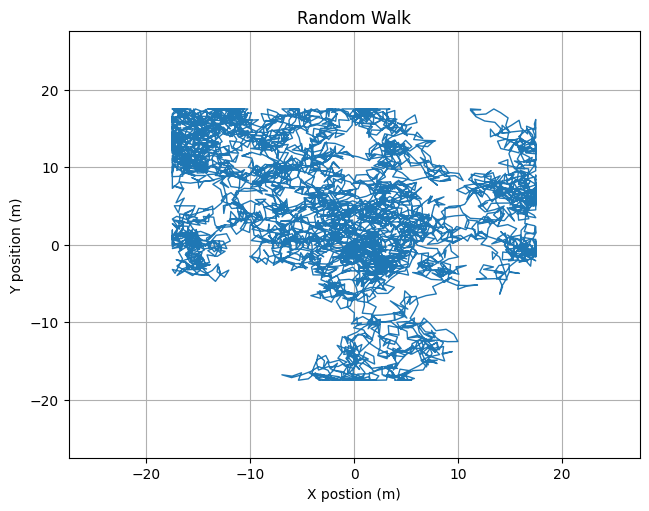

In [38]:
fig, ax = plt.subplots(1, 1)
x_data = BigX
y_data = BigY

ax.grid(True,'both',"both")
ax.plot(x_data, y_data, linewidth=1)
plt.tight_layout()
ax.set_ylabel("Y position (m)")
ax.set_xlabel("X postion (m)")
ax.set_title("Random Walk")

ax.set_xlim(-Length/2, Length/2)
ax.set_ylim(-Length/2, Length/2)

plt.show()

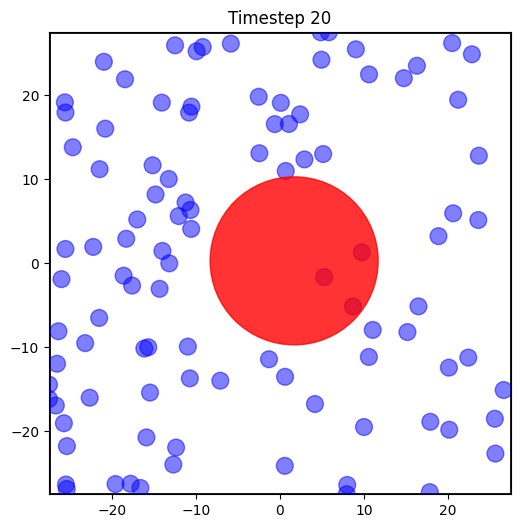

In [ ]:
def plot_frame(t):
    fig, ax = plt.subplots(figsize=(6,6))
    
    ax.set_xlim(-Length/2, Length/2)
    ax.set_ylim(-Length/2, Length/2)
    ax.set_aspect('equal')

    rect = patches.Rectangle((-Length/2, -Length/2), Length, Length,
                               fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)

    for x in range(len(SmallX)):
        circle = patches.Circle((SmallX[x][t], SmallY[x][t]), sRad,
                                  color='blue', alpha=0.5)
        ax.add_patch(circle)

    circle = patches.Circle((BigX[t], BigY[t]), bRad,
                              color='red', alpha=0.8)
    ax.add_patch(circle)

    plt.title(f'Timestep {t}')
    plt.show()

try:
    while True:
        for t in range(len(BigX)):
            clear_output(wait=True)
            plot_frame(t)
            time.sleep(0.01)
except KeyboardInterrupt:
    pass
except:
    print("There was an error, please wait while we fix it!")
else:
    pass